## Dependencies

In [5]:
import numpy as np
import nibabel as nib
import torch.nn.functional as F
import glob
import matplotlib.pyplot as plt
from tifffile import imwrite
from sklearn.preprocessing import MinMaxScaler
import torch
from pathlib import Path
import os
import splitfolders
import shutil

scaler=MinMaxScaler()
TRAIN_DATASET_PATH = Path('../data/brats20/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/')
VALIDATION_DATASET_PATH = Path('../data/brats20/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData')
file_number = np.random.randint(100,369)

## EDA

1854.603271484375
[0 1 2 4]
[0 1 2 3]
(240, 240, 155)
Slice number: 81


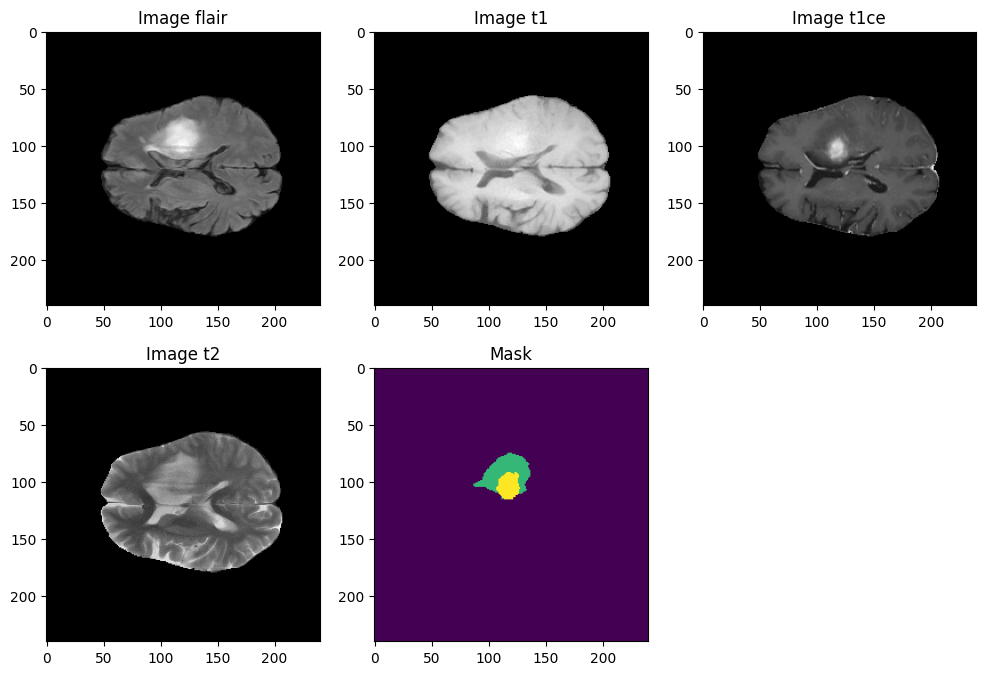

(240, 240, 155)


In [3]:
test_image_flair=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_flair.nii'))).get_fdata()
print(test_image_flair.max())
#Scalers are applied to 1D so let us reshape and then reshape back to original shape. 
test_image_flair=scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)


test_image_t1=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_t1.nii'))).get_fdata()
test_image_t1=scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)

test_image_t1ce=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_t1ce.nii'))).get_fdata()
test_image_t1ce=scaler.fit_transform(test_image_t1ce.reshape(-1, test_image_t1ce.shape[-1])).reshape(test_image_t1ce.shape)

test_image_t2=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_t2.nii'))).get_fdata()
test_image_t2=scaler.fit_transform(test_image_t2.reshape(-1, test_image_t2.shape[-1])).reshape(test_image_t2.shape)

test_mask=nib.load(next(TRAIN_DATASET_PATH.rglob('*355_seg.nii'))).get_fdata()
test_mask=test_mask.astype(np.uint8)

print(np.unique(test_mask))  #0, 1, 2, 4 (Need to reencode to 0, 1, 2, 3)
test_mask[test_mask==4] = 3  #Reassign mask values 4 to 3
print(np.unique(test_mask)) 

print(test_image_flair.shape)

import random
n_slice=random.randint(0, test_mask.shape[2]-1)
print('Slice number:',n_slice)

plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.imshow(test_image_flair[:,:,n_slice], cmap='gray')
plt.title('Image flair')
plt.subplot(232)
plt.imshow(test_image_t1[:,:,n_slice], cmap='gray')
plt.title('Image t1')
plt.subplot(233)
plt.imshow(test_image_t1ce[:,:,n_slice], cmap='gray')
plt.title('Image t1ce')
plt.subplot(234)
plt.imshow(test_image_t2[:,:,n_slice], cmap='gray')
plt.title('Image t2')
plt.subplot(235)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

print(test_mask.shape)

Original shape of input: (240, 240, 155, 3)
FInal shape of input: (128, 128, 128, 3)
Final shape of mask: (128, 128, 128)
Slice number: 20


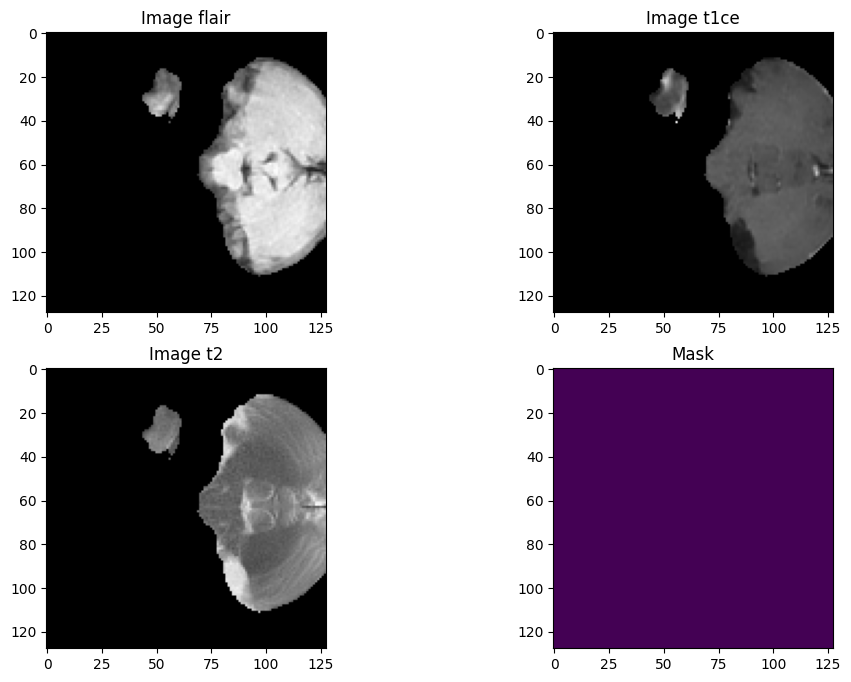

Encoded mask: torch.Size([128, 128, 128, 4])


In [4]:
combined_x = np.stack([test_image_flair, test_image_t1ce, test_image_t2], axis=3)
print("Original shape of input:",combined_x.shape)

#Crop to a size to be divisible by 64 so we can later extract 64x64x64 patches. 
#cropping x, y, and z
#combined_x=combined_x[24:216, 24:216, 13:141]

combined_x=combined_x[56:184, 56:184, 13:141] #Crop to 128x128x128x4
print("FInal shape of input:",combined_x.shape)

#Do the same for mask
test_mask_2 = test_mask[56:184, 56:184, 13:141]

print("Final shape of mask:",test_mask_2.shape)


n_slice=random.randint(0, test_mask_2.shape[2]-1)
print("Slice number:",n_slice)
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(combined_x[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(combined_x[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(combined_x[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask_2[:,:,n_slice])
plt.title('Mask')
plt.show()

test_mask_2 = F.one_hot(torch.tensor(test_mask_2).long(), num_classes=4)
print("Encoded mask:",test_mask_2.shape)

## Data Transform 1

### Helper function

In [2]:
def transform_nii_to_np(t2_list:list,t1ce_list:list,flair_list:list,mask_list:list,save_images:str,save_masks:str):

    os.makedirs(save_images,exist_ok=True)
    os.makedirs(save_masks,exist_ok=True)
    saved_samples = []
    discarded_samples = []
    
    for img in range(len(t2_list)):
        img_t2 = nib.load(filename=t2_list[img]).get_fdata()
        img_t2 = scaler.fit_transform(img_t2.reshape(-1,img_t2.shape[-1])).reshape(img_t2.shape)

        img_t1ce = nib.load(filename=t1ce_list[img]).get_fdata()
        img_t1ce = scaler.fit_transform(img_t1ce.reshape(-1,img_t1ce.shape[-1])).reshape(img_t1ce.shape)

        img_flair = nib.load(filename=flair_list[img]).get_fdata()
        img_flair = scaler.fit_transform(img_flair.reshape(-1,img_flair.shape[-1])).reshape(img_flair.shape)

        stacked_img = np.stack([img_flair,img_t1ce,img_t2],axis=3)
        stacked_img = stacked_img[56:184,56:184,13:141]

        img_mask = nib.load(filename=mask_list[img]).get_fdata().astype(np.uint8)
        img_mask[img_mask==4]=3
        img_mask = img_mask[56:184,56:184,13:141]

        val,counts = np.unique(img_mask,return_counts=True)

        if (1-(counts[0]/counts.sum())) > 0.01:
            saved_samples.append(img)
            img_mask_np = F.one_hot(torch.tensor(img_mask).long(),num_classes=4).numpy()
            np.save(file=f"../data/brats20/train_data_3channel/images/image_{img}.npy",arr=stacked_img)
            np.save(file=f"../data/brats20/train_data_3channel/masks/mask_{img}.npy",arr=img_mask_np)
        else:
            discarded_samples.append(img)

    return saved_samples,discarded_samples

### Training data

In [3]:
t2_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*t2.nii'))
t1ce_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*t1ce.nii'))
flair_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*flair.nii'))
mask_list = sorted(TRAIN_DATASET_PATH.rglob(pattern='*seg.nii'))
save_images = "../data/brats20/train_data_3channel/images/"
save_masks = "../data/brats20/train_data_3channel/masks/"

saved,discarded = transform_nii_to_np(t1ce_list=t1ce_list,
                    t2_list=t2_list,
                    flair_list=flair_list,
                    mask_list=mask_list,
                    save_images=save_images,
                    save_masks=save_masks)

print(f'Saved files: {len(saved)}\n\n {saved}\n\nDiscarded files: {len(discarded)} \n\n {discarded}')

Saved files: 344

 [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 61, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 79, 80, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99, 100, 101, 102, 103, 104, 105, 106, 108, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 139, 140, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 233, 234,

In [8]:
io_folder = "../data/brats20/train_data_3channel/"
splitfolders.ratio(input=io_folder,output = io_folder, seed = 42, ratio=(.75,.25),group_prefix = None)
shutil.rmtree(save_images)
shutil.rmtree(save_masks)

Copying files: 688 files [08:35,  1.33 files/s]


### Test data

In [ ]:
# t2_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*t2.nii'))
# t1ce_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*t1ce.nii'))
# flair_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*flair.nii'))
# mask_list = sorted(VALIDATION_DATASET_PATH.rglob(pattern='*seg.nii'))
# save_images = "../data/brats20/test_data_3channel/images/"
# save_masks = "../data/brats20/test_data_3channel/masks/"

# saved,discarded = transform_nii_to_np(t1ce_list=t1ce_list,
#                     t2_list=t2_list,
#                     flair_list=flair_list,
#                     mask_list=mask_list,
#                     save_images=save_images,
#                     save_masks=save_masks)

# print(f'Saved files: {len(saved)}\n\n {saved}\n\nDiscarded files: {len(discarded)} \n\n {discarded}')

IndexError: list index out of range

In [ ]:
# io_folder = "../data/brats20/test_data_3channel/"
# shutil.rmtree(save_images)
# shutil.rmtree(save_masks)